In [1]:
%load_ext autoreload
%autoreload 2

# Get parent root directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
from src.rocket import Rocket
from src.pos_rocket_vis import *
from LandMPC_part_7.nmpc_land import NmpcCtrl
import numpy as np

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir,"rocket.yaml")

# Rocket setup
Ts  = 1/20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1

In [3]:
sim_time = 10


x0=np.array([0.,0.,0.,0.,0.,np.deg2rad(30),0.,0.,0.,3.,2.,10.]) 
x_ref = np.array([0.,0.,0.,0.,0.,0.,0.,0.,0.,1.,0.,3.])

xs, us = rocket.trim(x_ref)
print("Linearization around a steady state:")
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)

H = 5.0  
nmpc = NmpcCtrl(rocket, H, xs, us)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Linearization around a steady state:
x_ref =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
us =  [ 0.          0.         56.66666667  0.        ]


      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |        0 (       0)   1.21ms ( 28.86us)        42
       nlp_g  |  19.00ms (452.38us)  31.68ms (754.31us)        42
  nlp_grad_f  |  16.00ms (372.09us)   1.82ms ( 42.26us)        43
  nlp_hess_l  | 445.00ms ( 10.85ms) 486.86ms ( 11.87ms)        41
   nlp_jac_g  | 180.00ms (  4.19ms) 161.20ms (  3.75ms)        43
       total  |   1.22 s (  1.22 s)   1.21 s (  1.21 s)         1


Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x00000195BE8BE440> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x00000195BE8BE440> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_cont

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=99, step=2), IntSlider(value=0,…

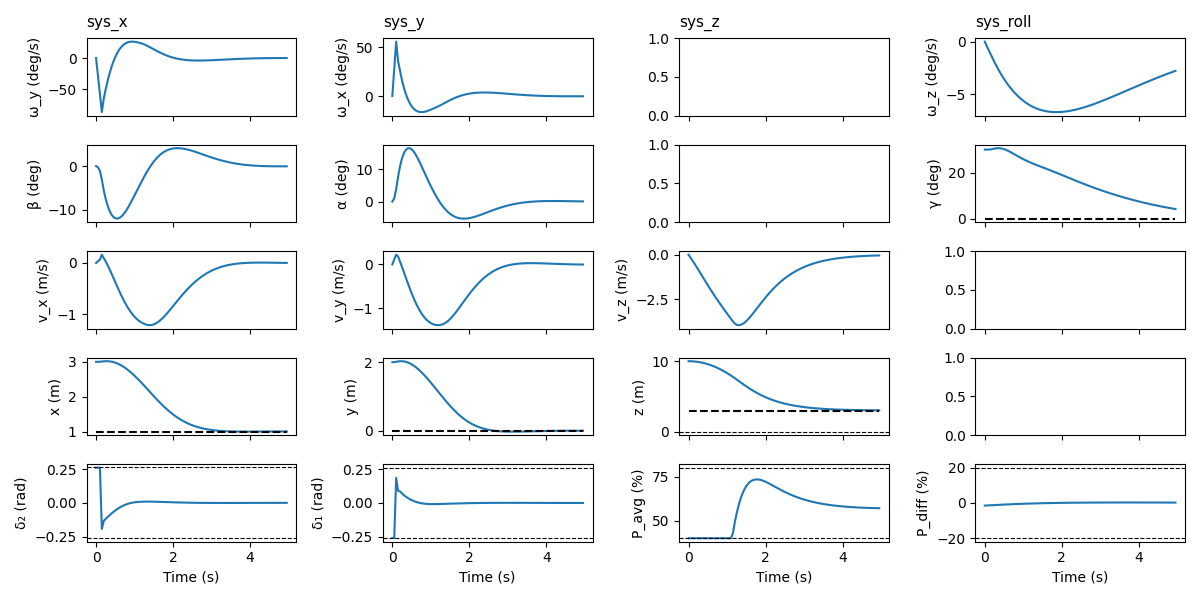

In [4]:
t0 = 0.0
u0, x_ol, u_ol, t_ol = nmpc.get_u(t0, x0)
vis.animate(t_ol[:-1], x_ol[:, :-1], u_ol)   
plot_static_states_inputs(t_ol[:-1], x_ol[:, :-1], u_ol, xs)

In [5]:
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol = rocket.simulate_land(nmpc, sim_time, H, x0)

Simulating time 0.00
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |        0 (       0)   1.38ms ( 32.81us)        42
       nlp_g  |  41.00ms (976.19us)  33.66ms (801.38us)        42
  nlp_grad_f  |        0 (       0)   1.91ms ( 44.30us)        43
  nlp_hess_l  | 485.00ms ( 11.83ms) 491.35ms ( 11.98ms)        41
   nlp_jac_g  | 150.00ms (  3.49ms) 164.48ms (  3.83ms)        43
       total  |   1.21 s (  1.21 s)   1.21 s (  1.21 s)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   2.00ms ( 41.67us)   1.31ms ( 27.35us)        48
       nlp_g  |  32.00ms (666.67us)  35.43ms (738.06us)        48
  nlp_grad_f  |        0 (       0)   2.14ms ( 47.51us)        45
  nlp_hess_l  | 529.00ms ( 12.30ms) 535.69ms ( 12.46ms)        43
   nlp_jac_g  | 172.00ms (  3.82ms) 170.00ms (  3.78ms)        45
       total  |   1.32 s (  1.32 s)   1.32 s (  1.32 s)         1
      solver  :   t_proc      (avg)   t_wall      (avg)

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

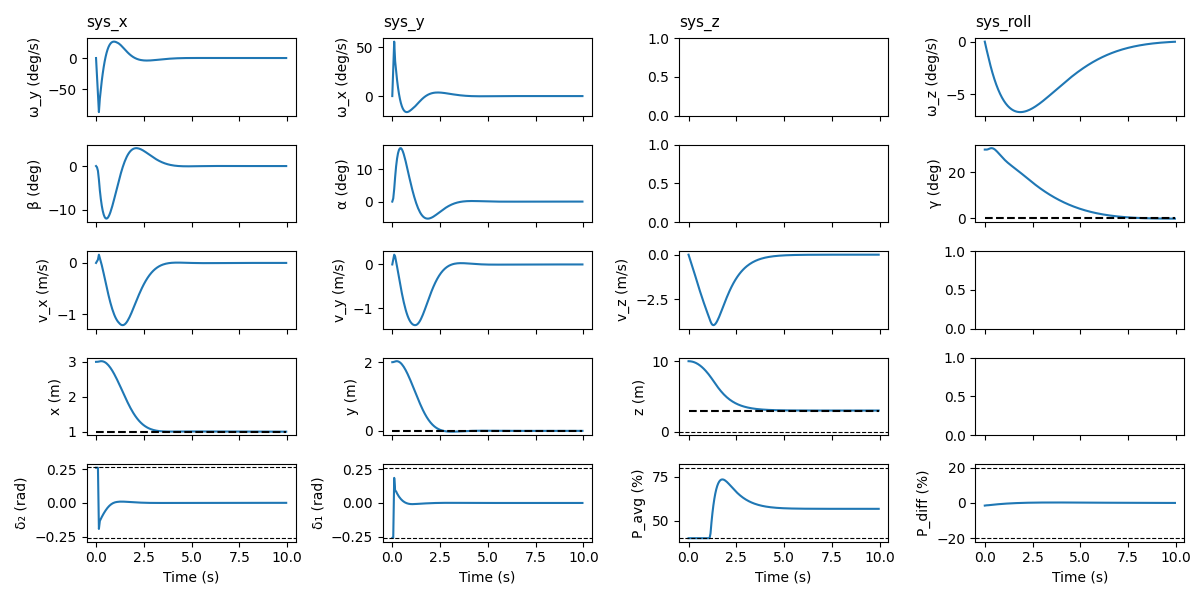

In [6]:
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol)
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs)